In [1]:
# import csv at ./raw_data/community_detection/csv1.csv
import csv
import os

def read_csv(file_path):
    """Read a CSV file and return its content as a list of dictionaries."""
    with open(file_path, mode='r', encoding='utf-8') as file:
        reader = csv.DictReader(file)
        return [row for row in reader]

file_path_1 = './raw_data/community_detection/csv1.csv'
file_path_2 = './raw_data/community_detection/csv2.csv'

if os.path.exists(file_path_1) and os.path.exists(file_path_2):
    data1 = read_csv(file_path_1)
    data2 = read_csv(file_path_2)

    # Print the first 5 rows of each dataset
    print("Data from csv1:")
    for row in data1[:5]:
        print(row)

    print("\nData from csv2:")
    for row in data2[:5]:
        print(row)

Data from csv1:
{'\ufefftitle': "*SAHRA* Ordinanza sugli emolumenti per l'esecuzione da parte delle autorità federali della legislazione in materia di trapianti (Ordinanza sugli emolumenti in materia di trapianti)", 'communityId': '1936'}
{'\ufefftitle': 'Accordi generali di credito del Fondo monetario internazionale 1962/1983 (con All. e lettera)', 'communityId': '16187'}
{'\ufefftitle': 'Accordo\t tra la Confederazione Svizzera e la Repubblica di El Salvador concernente la promozione e la protezione reciproche degli investimenti (con prot.)', 'communityId': '16187'}
{'\ufefftitle': 'Accordo\t tra la Confederazione Svizzera e la Repubblica di Moldavia concernente la promozione e la protezione reciproche degli investimenti', 'communityId': '16187'}
{'\ufefftitle': 'Accordo\t tra la Confederazione Svizzera e la Repubblica di Zambia concernente la promozione e la protezione reciproche degli investimenti', 'communityId': '16187'}

Data from csv2:
{'\ufeffcount': '1949', 'communityId': '29

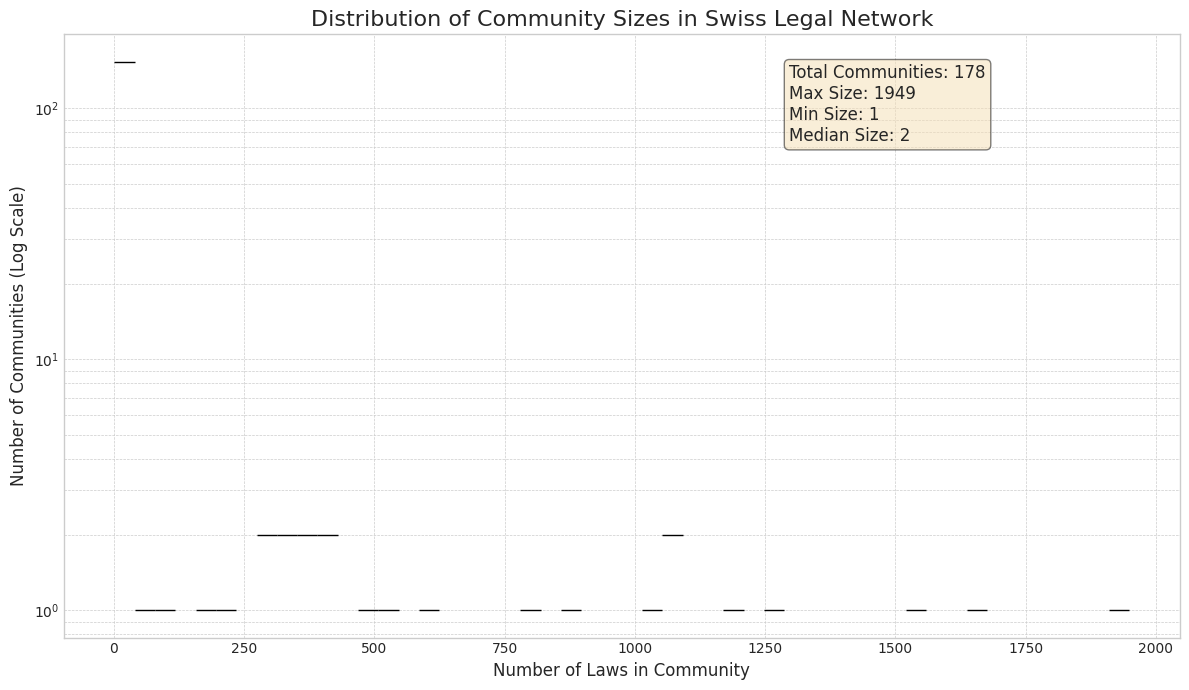

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the community size data
df_sizes = pd.read_csv('./raw_data/community_detection/csv2.csv')

# Plotting the distribution
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

sns.histplot(data=df_sizes, x='count', bins=50, ax=ax, log_scale=(False, True))
ax.set_title('Distribution of Community Sizes in Swiss Legal Network', fontsize=16)
ax.set_xlabel('Number of Laws in Community', fontsize=12)
ax.set_ylabel('Number of Communities (Log Scale)', fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add a text box with key statistics
stats_text = (f"Total Communities: {df_sizes.shape[0]}\n"
              f"Max Size: {df_sizes['count'].max()}\n"
              f"Min Size: {df_sizes['count'].min()}\n"
              f"Median Size: {df_sizes['count'].median():.0f}")
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.65, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

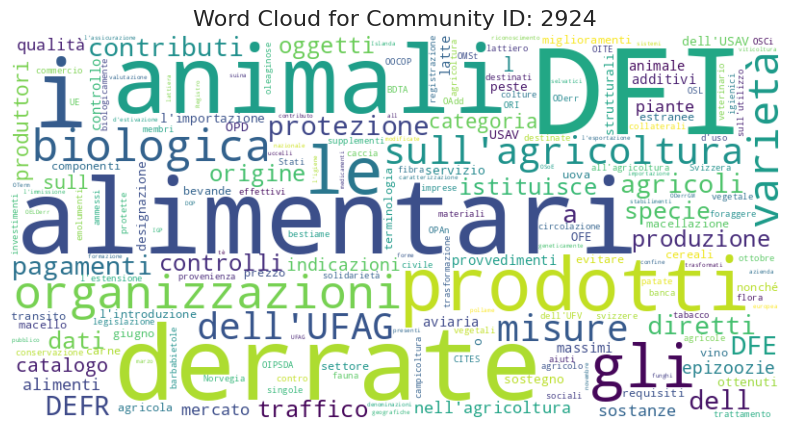

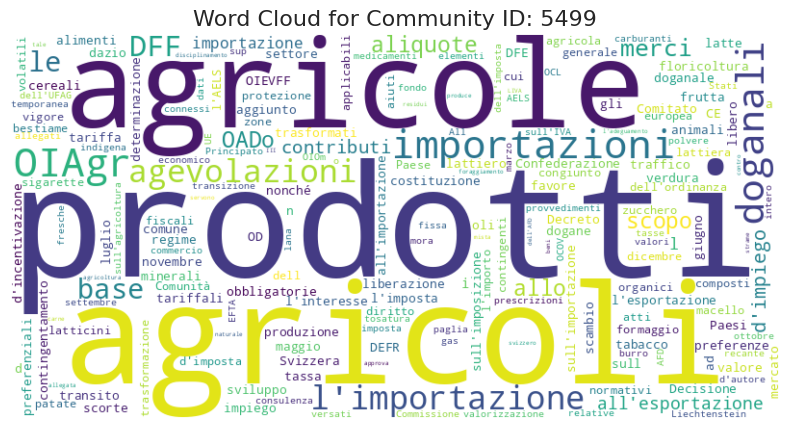

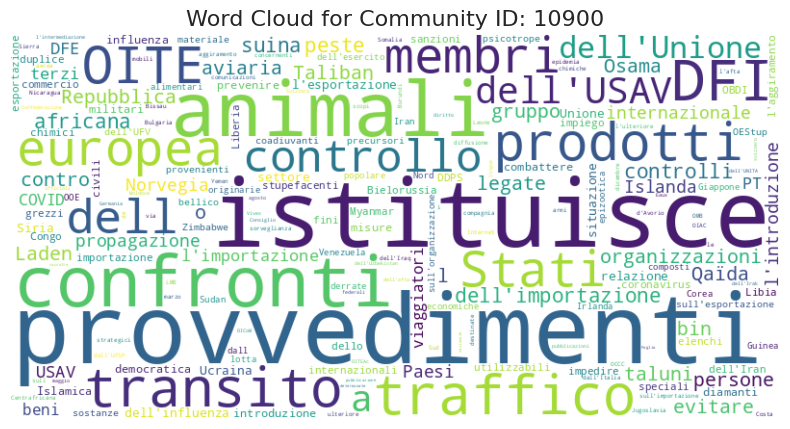

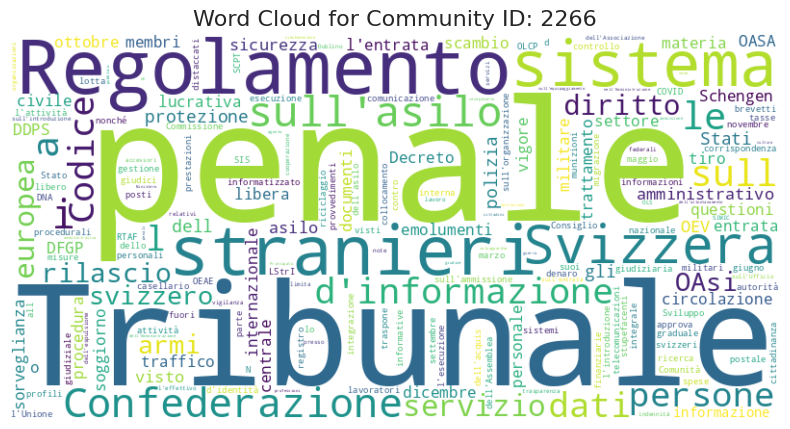

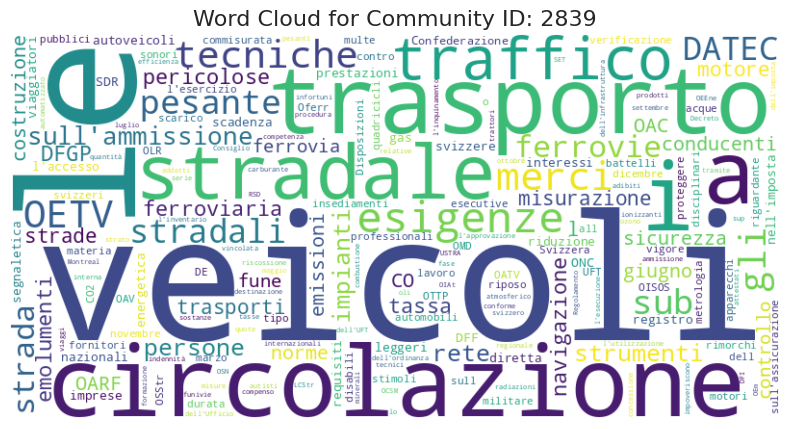

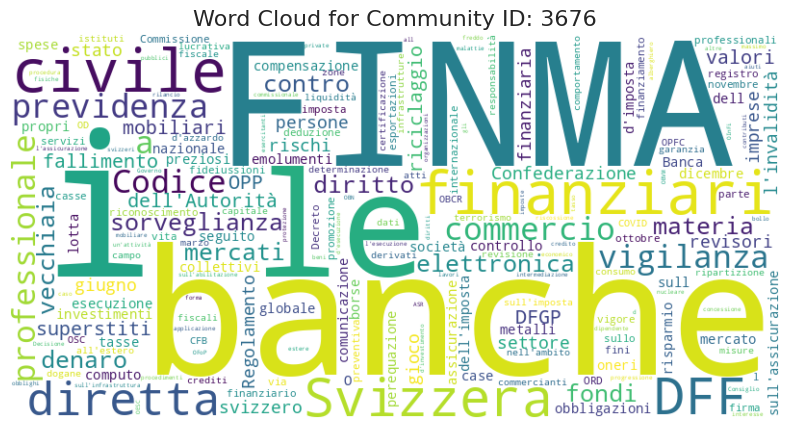

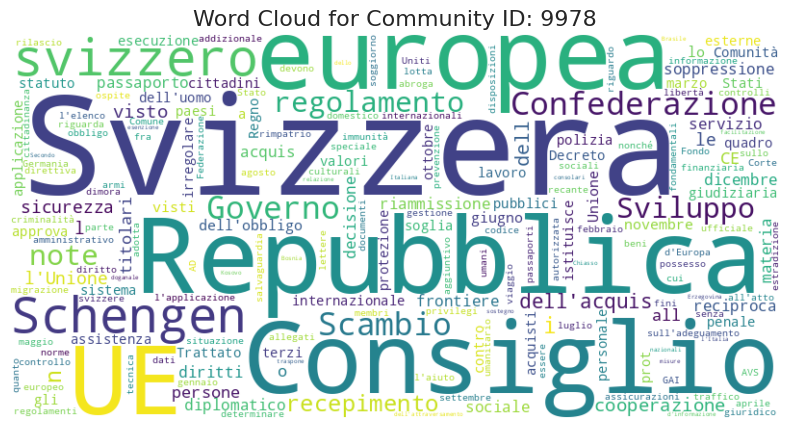

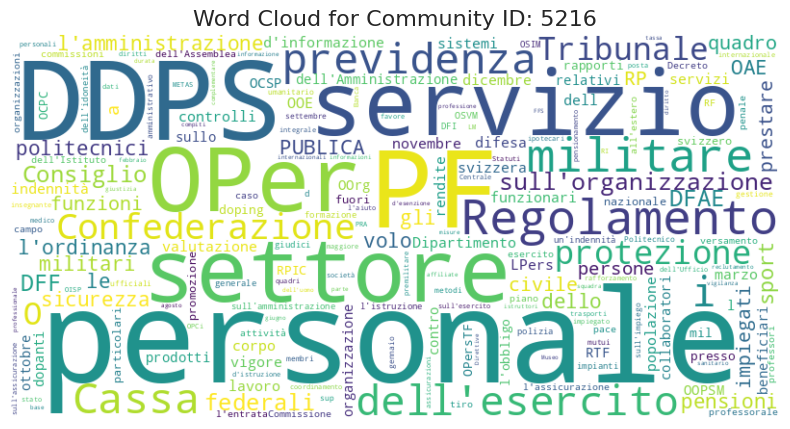

ValueError: We need at least 1 word to plot a word cloud, got 0.

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load the title data
df_titles = pd.read_csv('./raw_data/community_detection/csv1.csv')

# Italian stop words - add more if needed
stop_words_it = ['di', 'e', 'il', 'la', 'del', 'della', 'dei', 'degli', 'delle', 'un', 'una',
                 'in', 'che', 'per', 'con', 'sulla', 'sulle', 'sul', 'sui', 'tra', 'concernente',
                 'legge', 'federale', 'ordinanza', 'accordo', 'convenzione', 'protocollo',
                 'del', 'al', 'ai', 'agli', 'alla', 'alle', 'da', 'dal', 'dallo', 'dai', 'dagli',
                 'dalla', 'dalle', 'nel', 'nello', 'nei', 'negli', 'nella', 'nelle', 'su',
                 'sugli', 'sulla', 'sulle', 'questo', 'questa', 'questi', 'queste', 'modifica',
                 'relativo', 'relativa', 'non', 'sono', 'loro', 'ed', 'atto']

def generate_wordcloud_for_community(community_id, df):
    """Generates and displays a word cloud for a given community ID."""
    community_texts = df[df['communityId'] == community_id]['title']
    text_corpus = ' '.join(community_texts.astype(str))

    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          stopwords=stop_words_it, collocations=False).generate(text_corpus)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Community ID: {community_id}', fontsize=16)
    plt.show()

# Example usage for the top communities
generate_wordcloud_for_community(2924, df_titles)
generate_wordcloud_for_community(5499, df_titles)
generate_wordcloud_for_community(10900, df_titles)
generate_wordcloud_for_community(2266, df_titles)
generate_wordcloud_for_community(2839, df_titles)
generate_wordcloud_for_community(3676, df_titles)
generate_wordcloud_for_community(9978, df_titles)
generate_wordcloud_for_community(5216, df_titles)
generate_wordcloud_for_community(9689, df_titles)
generate_wordcloud_for_community(2670, df_titles)